In [1]:
import matplotlib.pyplot as plt
import numpy as np

from pyiron_glass import (
    melt_quench_simulation,
    generate_potential,
    get_ase_structure,
    get_structure_dict,
    read_lammps_dump,
    remove_atom_type,
    compute_coordination,
    compute_Qn,
    compute_network_connectivity,
    write_distribution_to_file,
    compute_angles,
    write_angle_distribution,
)

In [2]:
filename = "../data/SiONa_5.dump.gz"
cutoff_map = { # Cutoff distances for different atom types
    'O': 2.0,
    'Si': 2.0,
    'Na': 3.0,
}
# Atom type mapping (as per LAMMPS input)
type_map = {
    1: 'O',
    2: 'Si',
    3: 'Na',
}

network_formers = {'Si'}#, 'B', 'Al'}
modifiers = {'Na'}#, 'Ca'}
O_type = [t for t, e in type_map.items() if e == 'O'][0]
former_types = [t for t, e in type_map.items() if e in network_formers]
modifier_types = [t for t, e in type_map.items() if e in modifiers]

ids, types, coords, box_size = read_lammps_dump(filename, unwrap=False)

# Coordination distributions
O_coord, _ = compute_coordination(ids, types, coords, box_size, O_type, cutoff_map['O'], former_types)
former_coords = {type_map[t]: compute_coordination(ids, types, coords, box_size, t, cutoff_map[type_map[t]], [O_type])[0] for t in former_types}
modifier_coords = {type_map[t]: compute_coordination(ids, types, coords, box_size, t, cutoff_map[type_map[t]], [O_type])[0] for t in modifier_types}
Qn_dist = compute_Qn(ids, types, coords, box_size, cutoff_map['O'], former_types, O_type)

# Print results
print("\nO_n distribution:")

for n, c in O_coord.items():
    print(f"O_{n}: {c}")

for former, coord in former_coords.items():
    print(f"\n{former}_n distribution:")
    for n, c in coord.items():
        print(f"{former}_{n}: {c}")

for mod, coord in modifier_coords.items():
    print(f"\n{mod}_n distribution:")
    for n, c in coord.items():
        print(f"{mod}_{n}: {c}")

print("\nQn distribution:")
for n, c in sorted(Qn_dist.items()):
    print(f"Q_{n}: {c}")

total_formers = sum(len(v) for v in former_coords.values())
net_conn = compute_network_connectivity(Qn_dist)
print(f"\nNetwork connectivity: {net_conn:.4f}")


x = 45
# Write O_n distribution
write_distribution_to_file(x, "O_n.dat", O_coord, "O")

# Write each former type distribution
for former, coord in former_coords.items():
    write_distribution_to_file(x, f"{former}_n.dat", coord, former)

# Write each modifier type distribution
for mod, coord in modifier_coords.items():
    write_distribution_to_file(x, f"{mod}_n.dat", coord, mod)

# Write Qn distribution
write_distribution_to_file(x, "Qn.dat", Qn_dist, "Q")




O_n distribution:
O_1: 330
O_2: 6183

Si_n distribution:
Si_4: 3169
Si_5: 4

Na_n distribution:
Na_1: 1
Na_2: 14
Na_3: 69
Na_4: 112
Na_5: 78
Na_6: 44
Na_7: 13
Na_8: 3

Qn distribution:
Q_0: 0
Q_1: 0
Q_2: 9
Q_3: 312
Q_4: 2848
Q_5: 4
Q_6: 0

Network connectivity: 3.8973


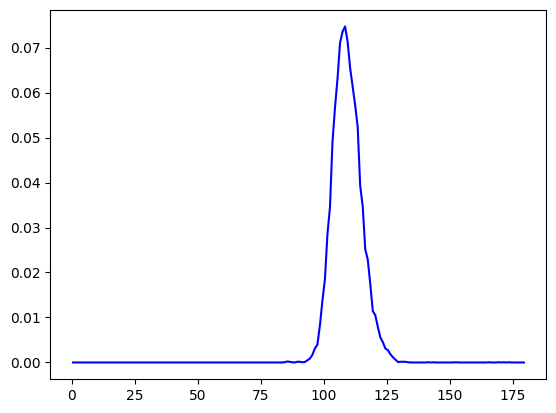

In [7]:

BAD = compute_angles(
    ids, types, coords, box_size,
    center_type=[2],
    neighbor_type=[1],  # Assuming Si is the center for O-Si-O angles
    cutoff=2,
    bins=180
)
plt.plot(
    BAD[0],
    BAD[1],
    label='O-Si-O angles',
    color='blue'
)
